# Kármán vortex street — DPIM reduction of a 58 000-DOF Navier–Stokes model

The 2D incompressible flow past a cylinder loses stability at $Re_c \approx 49$ through a
Hopf bifurcation — the Kármán vortex street. This notebook reduces the finite-element
model to a **single complex ODE** (a Stuart–Landau equation)

$$\dot z_1 = \lambda z_1 + c_{101}\,z_1\eta' + c_{210}\,z_1|z_1|^2 + \dots$$

by the Direct Parametrisation of Invariant Manifolds. The Reynolds number rides along as
a parametric coordinate $\eta' = 1/Re - 1/Re_0$, so **one** run at the expansion point
describes the whole bifurcation neighbourhood.

Run every cell top to bottom. At the FULL profile the order-9 solve is ~9 min and `W` is
~230 MB; `MORFE_FAST=1` gives a coarse-mesh order-3 smoke run in about a minute (a
different discretisation — it checks the pipeline, not the physics).

### What this notebook is investigating

The manifold has a singularity at $\rho \approx 1.95$, reached near $Re \approx 53$–54,
and that is what caps the limit-cycle branches well short of $Re = 70$. Each homological
solve inverts $(L - \mu_m B_1)$ on the outer block with $\mu_m = a\lambda_1 + b\bar\lambda_1$,
so a small $|\mu_m - \lambda_k|$ is a **near-resonance** that amplifies mode $k$'s
manifold component. The diagnostics below locate the offending mode and the
`PROMOTE_MODES` switch corrects it by promoting that mode alone, at order 1.

### One-time setup

```bash
python3 -m pip install jupyter nbconvert nbformat
julia --project=. -e 'using Pkg; Pkg.add("IJulia"); using IJulia; installkernel("Julia ex05", "--project=@.")'
```

In [1]:
using Pkg
Pkg.activate(@__DIR__)
if !isfile(joinpath(@__DIR__, "Manifest.toml"))
	# MORFE.jl is expected as a sibling checkout (MORFE.jl or MORFE_jl), next to this
	# repository or one directory above; override with ENV["MORFE_PATH"].
	morfe = get(ENV, "MORFE_PATH", "")
	if isempty(morfe)
		cands = [joinpath(@__DIR__, "..", "..", "..", n) for n in ("MORFE.jl", "MORFE_jl")]
		append!(cands, [joinpath(@__DIR__, "..", "..", "..", "..", n) for n in ("MORFE.jl", "MORFE_jl")])
		morfe = first(filter(isdir, cands))
	end
	Pkg.develop([Pkg.PackageSpec(path = morfe),
		Pkg.PackageSpec(path = joinpath(@__DIR__, "..", ".."))])
	Pkg.add(["Ferrite", "FerriteGmsh", "Gmsh", "Arpack", "LinearMaps", "StaticArrays", "KLU"])
end
Pkg.instantiate()

using MORFE, MORFEFerrite
using MORFEFerrite.FluidNavierStokes
using Ferrite, FerriteGmsh, Gmsh
using BifurcationKit
using LinearAlgebra, SparseArrays, Serialization, Printf, DelimitedFiles
using StaticArrays: SVector

# nbconvert and the VS Code kernel both run with the notebook's directory as cwd.
const HERE = @__DIR__

  Activating 

project at `~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street`


Precompiling packages...


   3818.7 ms  ✓ MORFEFerrite


   2565.9 ms  ✓ MORFEFerrite → MORFEFerriteWriteVTKExt
  2 dependencies successfully precompiled in 7 seconds. 156 already precompiled.


"/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street"

## 1 — Configuration

Everything tunable lives here.

In [2]:
FAST = get(ENV, "MORFE_FAST", "0") == "1"

# ── Physics ──────────────────────────────────────────────────────────────────
const Re₀ = 49.03            # expansion Re; the paper uses 20, Re_c≈49.03, 70, 80
const MAX_ORD = FAST ? 3 : 9 # DPIM order. The cohomological solve is GRADED, so the
# order-9 W/R contain every lower-order ROM exactly — one run covers the whole study.
const TRUNC_ORDERS = FAST ? [3] : [3, 5, 7, 9]
const N_EXT = 1              # external parameter dimensions (η′ = 1/Re − 1/Re₀)

# ── Mesh ─────────────────────────────────────────────────────────────────────
const MESH_H_CYL  = FAST ? 0.010 : 0.005
const MESH_H_WAKE = FAST ? 0.030 : 0.015
const MESH_H_BULK = FAST ? 0.080 : 0.04

# ── Eigensolver ──────────────────────────────────────────────────────────────
const EIG_NEV = FAST ? 20 : 40
const EIG_SIGMA_RE = 3.0     # ARPACK shift, offset from the imaginary axis so that
const EIG_SIGMA_IM = 8.0     # Re(λ_Hopf) ≈ 0 does not make the factorisation singular
const EIG_TARGET_FREQ = nothing   # nothing → smallest |Re λ| among Im λ > 0

# ── Mode gauge ───────────────────────────────────────────────────────────────
const MODE_SCALE = 1e-2      # uniform factor on BOTH eigenvector sides, for conditioning.
# Raw W/R from two different gauges are NOT comparable; `SpectralData` has no `scale`
# field precisely so this stays visible.

# Gauge for the master eigenvectors. SymmetricBiorthogonal scales BOTH sides by 1/√α;
# since α runs 1.1e-6 → 1.3e-8 across the promotable modes against 1.55e-6 for the Hopf
# pair, that inflates the promoted coordinates by up to ~1e4 and with them the η-series of
# W. Measured: it collapses the Reynolds radius of convergence from 1.88e-2 (un-promoted)
# to 2.56e-4 — smaller than |η| at every DNS point above Re 50, which is why promoted runs
# get monotonically WORSE with order (outside the radius, more terms is worse).
#
# LeftBiorthogonal puts the whole 1/α on ψ and leaves φ alone, so W's columns keep their
# natural scale. λ, c₁₀₁ and the Im/Re ratio of c₂₁₀ are gauge-free and must not move;
# c₂₁₀_re/im scale as |c|² and legitimately will.
const MODE_NORMALISATION = get(ENV, "MORFE_GAUGE", "symmetric") == "left" ?
	LeftBiorthogonal() : SymmetricBiorthogonal()
const GAUGE_TAG = MODE_NORMALISATION isa LeftBiorthogonal ? "_leftgauge" : ""

const REAL_MODE_RTOL = 1e-4  # a mode is REAL when |Im λ| ≤ this·|λ|. Relative, because
# ARPACK's numerical zero is ~1e-7, not ~1e-16: an absolute test calls a real mode
# complex and then invents a conjugate for it — a duplicate coordinate.

# ── Which outer modes join the master set ────────────────────────────────────
# Given as REAL PARTS of the eigenvalues to promote; a complex pair is matched by its
# real part and both halves are taken (the master set must be conjugation-invariant).
# Eigenvalues rather than indices, so the choice survives any change in ARPACK ordering.
#
#   MORFE_PROMOTE_MODES="-2.113875"              one mode
#   MORFE_PROMOTE_MODES="-2.113875,-5.135420"    two
#
# Promotion is a CHANGE OF COORDINATES: the mean-flow distortion becomes an explicit
# coordinate y_k instead of being folded into W. λ, c₁₀₁ and the effective Landau
# coefficient must therefore agree with an un-promoted run — that is what §9 checks.
const PROMOTE_MODES = let s = get(ENV, "MORFE_PROMOTE_MODES", "")
	isempty(s) ? Float64[] : parse.(Float64, strip.(split(s, ",")))
end
const PROMOTE_MATCH_RTOL = 1e-3   # |Re λ − target| ≤ this·|λ| counts as a match

# Safety filter, NOT a selection mechanism. α = ψᵀB₁φ is the denominator of the
# SymmetricBiorthogonal gauge (both sides ÷ √α), and B₁ is SINGULAR here — 6636 of 57860
# rows are P1 pressure DOFs, so this is a descriptor pencil whose null-space vectors are
# algebraic incompressibility modes with α = 0. Such a mode cannot carry a coordinate at
# all: ż = λz cannot be obtained by projecting with ψᵀB₁ when that projection is null,
# and 1/√α amplifies the eigenvector without bound. Relative to the Hopf pair's own α,
# since the absolute value depends on mesh and ARPACK scaling.
const PROMOTE_ALPHA_RTOL = 1e-4

const PROMOTED_CORE_ORD = 2  # highest (z₁,z̄₁,η′) degree a promoted coordinate may
# multiply. The promoted coordinate itself is FIRST ORDER either way; this bounds how far
# it MIXES. 2 closes the mean-flow loop and no more: ẏ_k is driven by z₁z̄₁ (core degree
# 2) and hands back through z₁·y_k (core degree 1). Keeping only the bare unit vectors
# removes the dominant stabilising term and turns this supercritical Hopf subcritical.

# Detuning tolerance for resonance detection, as a fraction of the MASTER frequency.
# ABSOLUTE, not `tol_relative`: MORFE scales a relative tolerance by each TARGET's own
# eigenvalue, and for an outer mode on the real axis the nearest superharmonic is s = 0 at
# distance exactly |λⱼ| — so the ratio is 1/tol_relative for EVERY real mode regardless of
# magnitude, and no real mode can ever be flagged.
const RESONANCE_TOL_FACTOR = isempty(PROMOTE_MODES) ? 0.1 : 0.5

# ── Limit-cycle branch ───────────────────────────────────────────────────────
const BRANCH_RE_MAX = 70.0
const BRANCH_RE_MIN = 40.0    # follow a fold down to here before giving up
const BRANCH_RHO_MAX = 15.0   # do not chase a disconnected root out to ρ ≈ 17
const BRANCH_DS0 = 1e-4
const BRANCH_MAX_STEPS = 2000

# ── DNS reference (§11, off by default) ──────────────────────────────────────
const FOM_REF_RE = [49.5, 50.5, 52.0, 54.0, 56.0, 58.0, 60.0, 62.0, 64.0]
const FOM_REF_SEED_ORD = 7    # seeding order; only sets the transient length
const FOM_REF_DT = 5e-4
const FOM_REF_TOL = 1e-4
const FOM_REF_N_SPINUP = 3
const FOM_REF_GAMMA = 0.0     # leave 0: any γ ≫ σ kills the shedding oscillation itself
const FOM_REF_MAX_PICARD = 400

@printf("profile: %s | order %d | promoting %s\n", FAST ? "FAST" : "FULL", MAX_ORD,
	isempty(PROMOTE_MODES) ? "nothing (Hopf pair only)" : string(PROMOTE_MODES))

profile: FAST | order 3 | promoting nothing (Hopf pair only)


## 2 — Mesh

Turek–Schäfer channel (2.2 × 0.41 m) with a ⌀0.1 m cylinder. Mesh *generation* stays
here in the example rather than in `src`: `setup_fem` only ever reads a `.msh`.

In [3]:
const _CHANNEL_L = 2.2
const _CHANNEL_H = 0.41
const _CYL_CX = 0.2
const _CYL_CY = 0.2
const _CYL_R = 0.05
const _CYL_D = 2.0 * _CYL_R   # cylinder diameter = 0.1 m (reference length)

# generate_mesh(; meshfile, h_cyl, h_wake, h_bulk) -> meshfile
#
# Linear triangles; P2/P1 Taylor-Hood DOFs are added by Ferrite's DofHandler, so
# quadratic geometry is unnecessary. Graded: h_cyl within r of the cylinder, h_wake in
# the wake corridor, h_bulk elsewhere. The defaults give n_free ≈ 57 860.
function generate_mesh(; meshfile::String = joinpath(HERE, "fem", "cylinder_flow.msh"),
		h_cyl::Float64 = 0.005, h_wake::Float64 = 0.015, h_bulk::Float64 = 0.04)
	mkpath(dirname(meshfile))
	gmsh.initialize()
	gmsh.option.setNumber("General.Terminal", 0)
	gmsh.model.add("TurekSchaefer")
	L, H = _CHANNEL_L, _CHANNEL_H
	cx, cy, r = _CYL_CX, _CYL_CY, _CYL_R

	p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, h_bulk)
	p2 = gmsh.model.geo.addPoint(L, 0.0, 0.0, h_bulk)
	p3 = gmsh.model.geo.addPoint(L, H, 0.0, h_bulk)
	p4 = gmsh.model.geo.addPoint(0.0, H, 0.0, h_bulk)
	l_bot = gmsh.model.geo.addLine(p1, p2)
	l_outlet = gmsh.model.geo.addLine(p2, p3)
	l_top = gmsh.model.geo.addLine(p3, p4)
	l_inlet = gmsh.model.geo.addLine(p4, p1)
	channel_loop = gmsh.model.geo.addCurveLoop([l_bot, l_outlet, l_top, l_inlet])

	pc = gmsh.model.geo.addPoint(cx, cy, 0.0, h_cyl)
	pe = gmsh.model.geo.addPoint(cx + r, cy, 0.0, h_cyl)
	pn = gmsh.model.geo.addPoint(cx, cy + r, 0.0, h_cyl)
	pw = gmsh.model.geo.addPoint(cx - r, cy, 0.0, h_cyl)
	ps = gmsh.model.geo.addPoint(cx, cy - r, 0.0, h_cyl)
	arc_ne = gmsh.model.geo.addCircleArc(pe, pc, pn)
	arc_nw = gmsh.model.geo.addCircleArc(pn, pc, pw)
	arc_ws = gmsh.model.geo.addCircleArc(pw, pc, ps)
	arc_se = gmsh.model.geo.addCircleArc(ps, pc, pe)
	# The channel loop is CCW; the cylinder loop must be CW to define a hole.
	cyl_loop = gmsh.model.geo.addCurveLoop([arc_ne, arc_nw, arc_ws, arc_se])
	domain_surf = gmsh.model.geo.addPlaneSurface([channel_loop, cyl_loop])
	gmsh.model.geo.synchronize()

	gmsh.model.mesh.field.add("Distance", 1)
	gmsh.model.mesh.field.setNumbers(1, "CurvesList", [arc_ne, arc_nw, arc_ws, arc_se])
	gmsh.model.mesh.field.setNumber(1, "Sampling", 300)
	gmsh.model.mesh.field.add("Threshold", 2)
	gmsh.model.mesh.field.setNumber(2, "InField", 1)
	gmsh.model.mesh.field.setNumber(2, "SizeMin", h_cyl)
	gmsh.model.mesh.field.setNumber(2, "SizeMax", h_bulk)
	gmsh.model.mesh.field.setNumber(2, "DistMin", r)
	gmsh.model.mesh.field.setNumber(2, "DistMax", 8.0 * r)
	gmsh.model.mesh.field.add("Box", 3)
	gmsh.model.mesh.field.setNumber(3, "VIn", h_wake)
	gmsh.model.mesh.field.setNumber(3, "VOut", h_bulk)
	gmsh.model.mesh.field.setNumber(3, "XMin", cx - r)
	gmsh.model.mesh.field.setNumber(3, "XMax", L)
	gmsh.model.mesh.field.setNumber(3, "YMin", cy - 4.0 * r)
	gmsh.model.mesh.field.setNumber(3, "YMax", cy + 4.0 * r)
	gmsh.model.mesh.field.add("Min", 4)
	gmsh.model.mesh.field.setNumbers(4, "FieldsList", [2, 3])
	gmsh.model.mesh.field.setAsBackgroundMesh(4)
	gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
	gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
	gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

	gmsh.model.addPhysicalGroup(1, [l_inlet], -1, "Inlet")
	gmsh.model.addPhysicalGroup(1, [l_outlet], -1, "Outlet")
	gmsh.model.addPhysicalGroup(1, [l_bot, l_top], -1, "Walls")
	gmsh.model.addPhysicalGroup(1, [arc_ne, arc_nw, arc_ws, arc_se], -1, "Cylinder")
	gmsh.model.addPhysicalGroup(2, [domain_surf], -1, "Domain")

	gmsh.model.mesh.generate(2)
	gmsh.model.mesh.optimize("Netgen")
	gmsh.write(meshfile)
	n_tri = length(gmsh.model.mesh.getElementsByType(2)[2]) ÷ 3
	@info "Mesh written to $meshfile ($n_tri triangles)"
	gmsh.finalize()
	return meshfile
end

r_mesh = @timed generate_mesh(; h_cyl = MESH_H_CYL, h_wake = MESH_H_WAKE, h_bulk = MESH_H_BULK)
meshfile = r_mesh.value

[ Info: Mesh written to /Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/fem/cylinder_flow.msh (3251 triangles)


"/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/fem/cylinder_flow.msh"

## 3 — FEM model and base flow

P2/P1 Taylor-Hood. Dirichlet BCs (Poiseuille inlet, no-slip walls and cylinder) are
eliminated; DPIM operates on the remaining `free_dpim` DOFs, where the perturbation
around the base flow vanishes on every prescribed boundary.

In [4]:
r_model = @timed fluid_model(meshfile; Re = Re₀)
case = r_model.value
show(stdout, MIME"text/plain"(), case)
println()
fom = case.fom
s₀_full = case.s₀_full

Info    : Reading '/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/fem/cylinder_flow.msh'...
Info    : 18 entities
Info    : 1708 nodes
Info    : 3416 elements
Info    : Done reading '/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/fem/cylinder_flow.msh'


[ Info: Grid: 3251 cells, 1708 nodes
[ Info: DOFs: 15042 total


[ Info:   Velocity per cell : 12  (range 1:12)
[ Info:   Pressure per cell : 3 (range 13:15)
[ Info:   Free DOFs (steady state) : 14436
[ Info:   Free DOFs (DPIM)         : 14436  (inlet frozen)


[ Info: FEM: 14436 free DOFs (steady state), 14436 (DPIM)
[ Info:   Newton iter 1 (Re₀ = 49.03): ‖R‖ = 0.121


[ Info:   Newton iter 2 (Re₀ = 49.03): ‖R‖ = 0.05361
[ Info:   Newton iter 3 (Re₀ = 49.03): ‖R‖ = 0.011


[ Info:   Newton iter 4 (Re₀ = 49.03): ‖R‖ = 0.003555
[ Info:   Newton iter 5 (Re₀ = 49.03): ‖R‖ = 0.0003321


[ Info:   Newton iter 6 (Re₀ = 49.03): ‖R‖ = 1.335e-6
[ Info:   Newton iter 7 (Re₀ = 49.03): ‖R‖ = 9.632e-11


[ Info: Linear operators assembled (Re₀ = 49.03)
[ Info:   B₁ nnz = 415710,  B₀ nnz = 415710
[ Info:   B₁ rank check: 12728 of 14436 diagonal entries nonzero
[ Info: K_visc assembled: 415710 nonzeros in free subspace


AssembledFluidModel (Ferrite P2/P1 Taylor-Hood)
  Re₀       : 49.03
  free DOFs : 14436 (steady state), 14436 (DPIM)
  operators : B₀ nnz=415710  B₁ nnz=415710  K_visc nnz=283866
  base flow : ‖s₀‖∞ = 2.311983752834523


15042-element Vector{Float64}:
  0.386278224997366
 -0.001178053483530107
  0.8881681938339028
  0.0067414211356737344
  0.3868858068844662
 -9.562680972605167e-5
  0.6346136318518725
  0.0008944824680589446
  0.6379325420114742
  0.0017853654580778032
  0.38648555467864365
 -0.0006671866678258141
  0.21244052411749687
  ⋮
  0.05597570198553378
  0.3314585875871053
 -0.005396905764275162
  0.0037096852727366435
  0.0
  0.0
  0.23910319234777444
 -0.0051415919384989565
  0.5268811432915488
 -0.00078893837185604
  0.6249009761799148
  0.00213288448944002

## 4 — Eigenproblem

Shift-invert ARPACK on $A_{lin} y = \lambda B_1 y$. Which modes span the manifold and
which are off-manifold targets is decided **here, in the driver** — the module has no
policy about it.

The shift $\sigma$ is complex, so ARPACK returns only the modes near $\sigma$: a
strongly oscillatory mode's conjugate sits near $\bar\sigma$ and is never computed.
Conjugates are synthesised analytically, which is exact for real $A, B$.

In [5]:
r_eig = @timed solve_hopf_eigenproblem(-case.B₀, case.B₁;
	nev = EIG_NEV, sigma_re = EIG_SIGMA_RE, sigma_im = EIG_SIGMA_IM,
	target_freq = EIG_TARGET_FREQ)
eig = r_eig.value

eig = let e = eig
	λ = collect(ComplexF64, e.eigenvalues)
	Φ = Matrix{ComplexF64}(e.right_modes)
	for k in eachindex(e.eigenvalues)
		# A REAL mode is UNPAIRED — it is its own conjugate and gets no partner.
		# Synthesising one would duplicate the coordinate.
		abs(imag(λ[k])) <= REAL_MODE_RTOL * abs(λ[k]) && continue
		# Near-real pairs sit about equally far from σ, so ARPACK returns both halves.
		any(l -> abs(l - conj(λ[k])) <= REAL_MODE_RTOL * abs(λ[k]), λ) && continue
		push!(λ, conj(λ[k]))
		Φ = hcat(Φ, conj.(e.right_modes[:, k]))
	end
	(; eigenvalues = λ, right_modes = Φ,
		hopf_index = e.hopf_index, conjugate_index = e.conjugate_index)
end
@printf("%d modes after adding analytic conjugates\n", length(eig.eigenvalues))

i_hopf = eig.hopf_index
i_hopf_conj = argmin(abs.(eig.eigenvalues .- conj(eig.eigenvalues[i_hopf])))
hopf = [i_hopf, i_hopf_conj]
outer_all = setdiff(eachindex(eig.eigenvalues), hopf)
@printf("λ_Hopf = %+.6f %+.6fi\n", real(eig.eigenvalues[i_hopf]), imag(eig.eigenvalues[i_hopf]))

  Shift σ = 3.0 + 8.0im,  nev = 20,  n = 14436



    #   Re(λ)           Im(λ)           |λ|         


  ────────────────────────────────────────────────────
    1      +0.000060    +16.842643     16.842643
    2      -2.113783     -0.000000      2.113783
    3      -2.910130     +0.010350      2.910148
    4      -2.910130     -0.010350      2.910148
    5      -5.123207     -0.000000      5.123207
    6      -6.673646     -0.000000      6.673646
    7     -10.283950     +4.491563     11.222022
    8     -11.047776     +7.512537     13.360074
    9      -6.570368    +18.363809     19.503826
   10      -9.394845     +0.486228      9.407419
   11     -11.296131    +10.686910     15.550326
   12      -9.394853     -0.486217      9.407427
   13     -11.543657     +2.158237     11.743679
   14     -12.037224    +13.987081     18.453542
   15     -11.472351     -0.000014     11.472351
   16     -13.204124     +3.980672     13.791107
   17     -14.116755     +8.657756     16.560178
   18     -14.025582     +5.975291     15.245361
   19     -13.566562     +1.659569     13.667691
   20     -14.

  20 modes computed, 6 on/near the real axis (|Im λ| ≤ 0.1)
32 modes after adding analytic conjugates


λ_Hopf = +0.000060 +16.842643i


## 5 — Near-resonance diagnostic

Each homological solve inverts $(L - \mu_m B_1)$ on the outer block, with
$\mu_m = a\lambda_1 + b\bar\lambda_1$. A small $|\mu_m - \lambda_k|$ means outer mode $k$
is nearly excited by that monomial and its manifold component is amplified by
$1/|\mu_m - \lambda_k|$.

This table is a **candidate ranking only** — a denominator is the amplification factor,
not the amplitude. §8 measures which mode is actually excited.

In [6]:
α_hopf_probe = nothing   # filled in §6; the table is printed again there with α ratios
dens = homological_denominators(eig.eigenvalues, hopf; max_ord = MAX_ORD,
	tol = RESONANCE_TOL_FACTOR * abs(eig.eigenvalues[i_hopf]))
println("smallest homological denominators |μ_m − λ_k|  (one row per outer mode)")
@printf("  %-9s %-26s %-12s %s\n", "|denom|", "λ_k", "monomial", "s=a−b")
for r in first(dens, 8)
	@printf("  %9.4f %-26s z₁^%d z̄₁^%d      %+d%s\n", r.denom,
		@sprintf("%+.6f %+.6fi", real(r.λ), imag(r.λ)), r.a, r.b, r.s,
		r.flagged ? "   ← inside detuning tol" : "")
end

smallest homological denominators |μ_m − λ_k|  (one row per outer mode)


  |denom|   λ_k                        monomial     s=a−b
     2.1139 -2.113783 -0.000000i       z₁^1 z̄₁^1      +0


     2.9103 -2.910130 -0.010350i       z₁^1 z̄₁^1      +0
     2.9103 -2.910130 +0.010350i       z₁^1 z̄₁^1      +0
     5.1233 -5.123207 -0.000000i       z₁^1 z̄₁^1      +0
     6.6738 -6.673646 -0.000000i       z₁^1 z̄₁^1      +0
     6.7442 -6.570368 +18.363809i      z₁^1 z̄₁^0      +1
     6.7442 -6.570368 -18.363809i      z₁^0 z̄₁^1      -1
     9.4075 -9.394845 +0.486228i       z₁^1 z̄₁^1      +0


## 6 — Mode selection

`PROMOTE_MODES` names the outer modes that join the master set, matched by real part and
closed under conjugation. The α filter is a **safety check** on that choice, not a
selection mechanism: a mode whose pairing $\alpha = \psi^\mathsf{T} B_1 \varphi$ is
essentially null cannot carry a coordinate at all, and the run refuses rather than
dividing by $\sqrt\alpha \approx 0$.

In [7]:
probe_mset = all_multiindices_up_to(2 + N_EXT, MAX_ORD; min_degree = 1)
probe = build_model(case, eig; master = hopf, outer = outer_all,
	n_monomials = length(probe_mset), scale = MODE_SCALE, conjugate_atol = REAL_MODE_RTOL,
	normalisation = MODE_NORMALISATION)
α_hopf = abs(probe.meta.bilinear_pairings[1])
@printf("|α_Hopf| = %.3e   (keep ≥ %.3g·|α_Hopf|)\n\n", α_hopf, PROMOTE_ALPHA_RTOL)

promoted = Int[]
if !isempty(PROMOTE_MODES)
	@printf("  %-5s %-26s %-11s %-11s %s\n", "mode", "λ", "|α|", "|α|/|α_H|", "verdict")
	for target in PROMOTE_MODES
		hits = [k for k in outer_all
				if abs(real(eig.eigenvalues[k]) - target) <=
				   PROMOTE_MATCH_RTOL * max(abs(eig.eigenvalues[k]), 1.0)]
		isempty(hits) && error("no outer mode with Re λ ≈ $target — check PROMOTE_MODES")
		for k in hits
			local α
			try
				(_, _, α) = left_eigenvector(-case.B₀, case.B₁,
					eig.eigenvalues[k], eig.right_modes[:, k]; scale = MODE_SCALE)
			catch err
				error("adjoint solve failed for λ ≈ $target: $(typeof(err))")
			end
			ratio = abs(α) / α_hopf
			ratio < PROMOTE_ALPHA_RTOL && error(
				"mode λ = $(eig.eigenvalues[k]) has |α|/|α_Hopf| = $ratio < " *
				"$PROMOTE_ALPHA_RTOL — its pairing is null (an algebraic constraint mode " *
				"of the singular B₁), so it cannot carry a master coordinate.")
			@printf("  %-5d %-26s %-11.3e %-11.3e keep\n", k,
				@sprintf("%+.6f %+.6fi", real(eig.eigenvalues[k]), imag(eig.eigenvalues[k])),
				abs(α), ratio)
			push!(promoted, k)
		end
	end
	# Conjugation closure: a complex mode and its conjugate are ONE physical mode and must
	# be promoted together, or the manifold is not conjugation-invariant and the ROM has no
	# real realisation. A REAL mode is its own conjugate and adds nothing here.
	for k in copy(promoted)
		abs(imag(eig.eigenvalues[k])) <= REAL_MODE_RTOL * abs(eig.eigenvalues[k]) && continue
		p = argmin(abs.(eig.eigenvalues .- conj(eig.eigenvalues[k])))
		p in hopf || push!(promoted, p)
	end
	promoted = sort(unique(promoted))
end

master = vcat(hopf, promoted)
outer = setdiff(eachindex(eig.eigenvalues), master)
ROM_FULL = length(master)
NVAR_FULL = ROM_FULL + N_EXT
RESONANCE_TOL = RESONANCE_TOL_FACTOR * abs(eig.eigenvalues[i_hopf])

# The run directory is named by the MASTER-MODE COUNT, and is computed here — after the
# selection, before anything is written. Downstream cells discover it rather than
# rebuilding the path: when they built it independently they drifted, and a days-old
# directory from a different mode set was validated silently.
RESULTS_DIR = joinpath(HERE, "results", @sprintf("Re%.2f_ord%d_%dmodes%s", Re₀, MAX_ORD, ROM_FULL, GAUGE_TAG))
DATA_DIR = joinpath(RESULTS_DIR, "data")
mkpath(DATA_DIR)
@printf("\nROM = %d, NVAR = %d, %d promoted → %s\n",
	ROM_FULL, NVAR_FULL, length(promoted), basename(RESULTS_DIR))

|α_Hopf| = 6.273e-06   (keep ≥ 0.0001·|α_Hopf|)


ROM = 2, NVAR = 3, 0 promoted → Re49.03_ord3_2modes


## 7 — Monomial set and the cohomological solve

Order `MAX_ORD` in $(z_1, \bar z_1, \eta')$, and order **1** in each promoted coordinate:
a monomial may carry at most one promoted coordinate, to the first power.

The mixed terms are the point. A promoted mode is driven quadratically by the oscillation
($\dot y_k$ gets a $z_1\bar z_1$ term — the mean-flow distortion) and acts back on the
oscillator through $z_1 y_k$. Keeping only the bare unit vectors $y_k$ would compute the
distortion and give it no path back to $\dot z_1$, removing the dominant stabilising
contribution to $c_{210}$ and turning this supercritical Hopf subcritical.

In [8]:
mset_exps = SVector{NVAR_FULL, Int}[]
_core(a, b, c, p) = SVector{NVAR_FULL, Int}(ntuple(
	i -> i == 1 ? a : i == 2 ? b : i == NVAR_FULL ? c : (i == 2 + p ? 1 : 0), NVAR_FULL))
for a in 0:MAX_ORD, b in 0:MAX_ORD, c in 0:MAX_ORD
	core = a + b + c
	core <= MAX_ORD || continue
	core >= 1 && push!(mset_exps, _core(a, b, c, 0))
	core <= PROMOTED_CORE_ORD || continue
	core + 1 <= MAX_ORD || continue
	for p in 1:length(promoted)
		push!(mset_exps, _core(a, b, c, p))
	end
end
mset = MultiindexSet(mset_exps)
n_mixed = count(e -> sum(@view e[3:(NVAR_FULL - 1)]) > 0, mset_exps)

r_build = @timed build_model(case, eig; master = master, outer = outer,
	n_monomials = length(mset), scale = MODE_SCALE, conjugate_atol = REAL_MODE_RTOL,
	normalisation = MODE_NORMALISATION)
(; model, spectral, meta) = r_build.value
@printf("W will be %.0f MB  (%d free DOFs × %d monomials × 16 B)\n",
	case.info.n_free_dpim * length(mset) * 16 / 1024^2, case.info.n_free_dpim, length(mset))
@printf("%d monomials (%d core ≤ %d, %d carrying one promoted coordinate)\n",
	length(mset), length(mset) - n_mixed, MAX_ORD, n_mixed)
println("conjugate permutation: ", meta.conjugate_permutation)

r_dpim = @timed parametrise(model, spectral, mset;
	resonance = ResonanceConfig(style = :complex_normal_form, tol = RESONANCE_TOL,
		# Detection on the FULL complex eigenvalues: the growth rate is part of the
		# distance, which is what separates a genuinely resonant mode from one that
		# merely shares a frequency while being strongly damped.
		eigenvalue_projection = :full, outer_targets = true),
	conjugate_permutation = meta.conjugate_permutation)
(W, R) = r_dpim.value
@printf("solve: %.1f s\n", r_dpim.time)

W will be 4 MB  (14436 free DOFs × 19 monomials × 16 B)
19 monomials (19 core ≤ 3, 0 carrying one promoted coordinate)


conjugate permutation: 

[2, 1, 3]


┌ Info: conjugate_permutation is active — the following assumptions must hold:
│   1. Real-valued FOM: all matrices in model.linear_terms and all nonlinear/force terms must have real-valued entries (eltype <: Real or purely-real complex).
│   2. Each mode either comes in a complex conjugate pair with another mode, or is self-paired  meaning it has a real eigenvalue and a real-valued mode shape.
│   3. Eigenvalue conjugacy is necessary but NOT sufficient for paired modes; the eigenvectors must satisfy master_modes[:, perm[r]] = conj(master_modes[:, r]).
│   4. If external modes are present (N_EXT > 0): the same pairing rules apply to the external eigenvalues, encoded in the NVAR-length permutation.
└ Passing an incorrect permutation silently corrupts the parametrisation and reduced-dynamics.
┌ Info: Using optimised FEM path: cached per-element loop
└   n_fem_terms = 1


solve: 11.1 s


## 8 — Save, and report the reduced dynamics

Row 1 is the Stuart–Landau equation; row 2 is its conjugate and the last row is
$\dot\eta' = 0$. Supercritical Hopf ⟺ $\mathrm{Re}\,c_{210} < 0$.

In [9]:
master_eigenvalues = collect(eig.eigenvalues[master])
_disp = sort(findall(λ -> imag(λ) > 0.1, eig.eigenvalues);
	by = i -> abs(real(eig.eigenvalues[i])))

MORFE.save_rom(RESULTS_DIR, W, R; external_system = meta.external_system,
	metadata = ["example" => "05_karman_vortex_street", "fast" => FAST])
export_reduced_dynamics(stdout, DATA_DIR, R, master_eigenvalues;
	re0 = Re₀, ord = MAX_ORD, nvar = NVAR_FULL)

(l_free, L0_lift) = lift_functional(case)
L_coeffs_lift = export_lift_polynomial(stdout, DATA_DIR, W, l_free, L0_lift)
(M_vel, vel_rows, area) = prepare_energy_gram(fom)
write_energy_gram(DATA_DIR, W, M_vel, vel_rows, area)
export_vtk_bundle(DATA_DIR, fom, s₀_full, master_eigenvalues,
	eig.eigenvalues[_disp], eig.right_modes[:, _disp])
export_lift_csv(stdout, DATA_DIR, mset, L0_lift, L_coeffs_lift)

write_summary(stdout, joinpath(RESULTS_DIR, "summary.txt"), case; rom = meta,
	title = "Kármán Vortex Street DPIM — Summary  " *
			"(Re₀ = $Re₀, order = $MAX_ORD, NVAR = $NVAR_FULL)",
	metadata = ["mesh_time_s" => @sprintf("%.3f", r_mesh.time),
		"solve_time_s" => @sprintf("%.3f", r_dpim.time),
		"resonance_eigenvalues" => "full", "resonance_tol" => RESONANCE_TOL,
		"outer_targets" => true,
		"nvar" => NVAR_FULL, "n_promoted" => length(promoted),
		"promoted_modes" => isempty(promoted) ? "none" : join(promoted, " "),
		"promote_modes_cfg" => isempty(PROMOTE_MODES) ? "none" : join(PROMOTE_MODES, " "),
		"promote_alpha_rtol" => PROMOTE_ALPHA_RTOL,
		"mode_normalisation" => string(typeof(MODE_NORMALISATION).name.name),
		"promoted_core_ord" => PROMOTED_CORE_ORD,
		"mesh_h_cyl" => MESH_H_CYL, "mesh_h_wake" => MESH_H_WAKE,
		"mesh_h_bulk" => MESH_H_BULK, "fast" => FAST])


Reduced dynamics ż₁ = R₁ — nonzero monomials:


  [1, 0, 0]      : 5.97175e-5 + 16.8426im
  [1, 0, 1]      : -211.728 - 55.332im
  [2, 1, 0]      : -0.111649 + 0.071279im
  [1, 0, 2]      : 2898.87 - 311.56im
  Lift polynomial: L0 = 0.000416, 19 coefficients
  L_coefficients.csv  (19 polynomial rows, L0 = 0.000416448)

──────────────────────────────────────────────────────────────────────────────
Kármán Vortex Street DPIM — Summary  (Re₀ = 49.03, order = 3, NVAR = 3)
  FOM size : 14436 free DOFs
──────────────────────────────────────────────────────────────────────────────
  fem                                   2.085 s
  steady                                2.943 s
  ops                                   0.326 s
  kvisc                                 0.245 s
  TOTAL (timed stages)                  5.600 s
──────────────────────────────────────────────────────────────────────────────


## 9 — Convergence diagnostic

Ratio test on $\|W\|$ per degree. A ratio that **settles** to a constant is the signature
of a genuine analytic singularity, and its reciprocal gives the radius; a ratio that keeps
growing would instead indicate round-off contamination.

⚠️ **Valid within this run only.** Promoted coordinates each carry a $1/\sqrt\alpha$
scaling and $\alpha$ spans orders of magnitude across modes, so $\|W\|$ along the backbone
means a different thing in each coordinate system. Runs are compared on observables
(§11–12), never on this.

`modal_growth` is the measurement §5 cannot make: it decomposes the backbone into outer
modes and ranks them by how fast each is **actually excited** as the order grows —
numerator included, not just the denominator.

In [10]:
diag = manifold_ratio_test(W)
println("amplitude backbone z₁^(n+1) z̄₁^n:")
@printf("  %-5s %-14s %-11s %s\n", "deg", "‖W‖", "ratio", "implied ρ_conv")
for r in diag.amplitude
	@printf("  %-5d %-14.5e %-11s %s\n", r.deg, r.norm,
		isnan(r.ratio) ? "—" : @sprintf("%.3e", r.ratio),
		isnan(r.rho_conv) ? "—" : @sprintf("%.2f", r.rho_conv))
end
println("\nReynolds direction η′^n:")
@printf("  %-5s %-14s %-11s %s\n", "deg", "‖W‖", "ratio", "implied η_conv")
for r in diag.eta
	@printf("  %-5d %-14.5e %-11s %s\n", r.deg, r.norm,
		isnan(r.ratio) ? "—" : @sprintf("%.3e", r.ratio),
		isnan(r.eta_conv) ? "—" : @sprintf("%.3e", r.eta_conv))
end
if diag.valid
	@printf("\nρ_conv ≈ %.2f — the branch leaves the radius where its amplitude passes this\n",
		diag.rho_conv)
	@printf("η_conv ≈ %.3e (|η′| at Re 70 is %.3e — %s)\n", diag.eta_conv,
		abs(1 / 70 - 1 / Re₀), abs(1 / 70 - 1 / Re₀) < diag.eta_conv ? "inside" : "OUTSIDE")
else
	println("\nρ_conv/η_conv not reported: this run has promoted coordinates, so the")
	println("mean-flow content has moved out of the pure backbone z₁^(n+1)z̄₁^n and into")
	println("the mixed monomials z₁^a z̄₁^b y_k. The backbone norms above are a RESIDUAL,")
	println("not a radius — reporting them gave ρ_conv = 0.67 for a run accurate against")
	println("DNS out to ρ ≈ 2.1. Compare runs on observables (§13) instead.")
end

# Store ρ_conv for figures.py: it marks where each curve stops being trustworthy.
open(joinpath(DATA_DIR, "convergence.txt"), "w") do io
	@printf(io, "rho_conv = %.6f\n", diag.rho_conv)
	@printf(io, "eta_conv = %.6e\n", diag.eta_conv)
	println(io, "valid = ", diag.valid)
end

amplitude backbone z₁^(n+1) z̄₁^n:
  deg   ‖W‖            ratio       implied ρ_conv
  1     3.99278e+00    —           —


  3     7.90687e-01    1.980e-01   2.25

Reynolds direction η′^n:
  deg   ‖W‖            ratio       implied η_conv
  1     1.04105e+03    —           —
  2     2.38462e+04    2.291e+01   4.366e-02
  3     1.13080e+06    4.742e+01   2.109e-02

ρ_conv ≈ 2.25 — the branch leaves the radius where its amplitude passes this
η_conv ≈ 2.109e-02 (|η′| at Re 70 is 6.110e-03 — inside)


In [11]:
# Which outer mode is actually excited as the order grows? This needs the LEFT
# eigenvectors, so it re-runs the adjoint solves (≈ one per outer mode). Set to false to
# skip — it is diagnostic only and does not feed the ROM.
const RUN_MODAL_GROWTH = true

if RUN_MODAL_GROWTH && !isempty(outer)
	keep = first(outer, min(12, length(outer)))
	ψcols = ComplexF64[]
	λkeep = ComplexF64[]
	ok = Int[]
	for k in keep
		try
			(ψk, _, _) = left_eigenvector(-case.B₀, case.B₁,
				eig.eigenvalues[k], eig.right_modes[:, k]; scale = MODE_SCALE)
			append!(ψcols, ψk)
			push!(λkeep, eig.eigenvalues[k])
			push!(ok, k)
		catch err
			@warn "adjoint solve failed for mode $k: $(typeof(err))"
		end
	end
	if !isempty(ok)
		Ψ = reshape(ψcols, :, length(ok))
		mg = modal_growth(W, case.B₁, Ψ, λkeep)
		println("modal content of the amplitude backbone, degrees ", mg.degrees)
		@printf("  %-26s %-12s %s\n", "λ_k", "growth", "amplitudes by degree")
		for r in first(mg.modes, 8)
			@printf("  %-26s %-12s %s\n",
				@sprintf("%+.6f %+.6fi", real(r.λ), imag(r.λ)),
				isnan(r.growth) ? "—" : @sprintf("%.3e", r.growth),
				join((@sprintf("%.2e", a) for a in r.amplitudes), "  "))
		end
		println("\nThe top row is the mode whose manifold component grows fastest with")
		println("order — the one limiting the expansion. Promote it via PROMOTE_MODES.")
	end
end

┌ Warning: Degenerate bilinear pairing ψᵀBφ = 3.848275588361211e-14 + 4.013557387562482e-13im for λ = -10.2839499695696 + 4.491563179247713im. The left and right vectors do not belong to the same mode, so this mode cannot carry a master coordinate — its normalisation divides by ~0. Check that the eigenvalue is converged and simple.
└ @ MORFEFerrite.FluidNavierStokes ~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/src/FluidNavierStokes/eigensolver.jl:219
┌ Warning: Degenerate bilinear pairing ψᵀBφ = 2.6009622436733327e-13 + 3.3572701275408825e-13im for λ = -11.047776348425298 + 7.5125369350114015im. The left and right vectors do not belong to the same mode, so this mode cannot carry a master coordinate — its normalisation divides by ~0. Check that the eigenvalue is converged and simple.
└ @ MORFEFerrite.FluidNavierStokes ~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/src/FluidNavierStokes/eigensolver.jl:219


┌ Warning: Degenerate bilinear pairing ψᵀBφ = 2.3243371429114133e-12 + 4.81984033605896e-13im for λ = -9.394844634090527 + 0.4862279520153132im. The left and right vectors do not belong to the same mode, so this mode cannot carry a master coordinate — its normalisation divides by ~0. Check that the eigenvalue is converged and simple.
└ @ MORFEFerrite.FluidNavierStokes ~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/src/FluidNavierStokes/eigensolver.jl:219
┌ Warning: Degenerate bilinear pairing ψᵀBφ = 1.0082387277445712e-12 + 9.569989626033793e-13im for λ = -11.296131261197756 + 10.686910074478607im. The left and right vectors do not belong to the same mode, so this mode cannot carry a master coordinate — its normalisation divides by ~0. Check that the eigenvalue is converged and simple.
└ @ MORFEFerrite.FluidNavierStokes ~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/src/FluidNavierStokes/eigensolver.jl:219


┌ Warning: Degenerate bilinear pairing ψᵀBφ = -9.932121601689396e-13 - 2.1560340832957414e-12im for λ = -9.394853391647306 - 0.48621693343706696im. The left and right vectors do not belong to the same mode, so this mode cannot carry a master coordinate — its normalisation divides by ~0. Check that the eigenvalue is converged and simple.
└ @ MORFEFerrite.FluidNavierStokes ~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/src/FluidNavierStokes/eigensolver.jl:219
┌ Warning: Degenerate bilinear pairing ψᵀBφ = 3.913416784743787e-13 + 2.643808719891159e-13im for λ = -11.543656933844437 + 2.1582366941598288im. The left and right vectors do not belong to the same mode, so this mode cannot carry a master coordinate — its normalisation divides by ~0. Check that the eigenvalue is converged and simple.
└ @ MORFEFerrite.FluidNavierStokes ~/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/src/FluidNavierStokes/eigensolver.jl:219


modal content of the amplitude backbone, degrees 

[1, 3]
  λ_k                        growth       amplitudes by degree
  -9.394845 +0.486228i       7.942e-01    1.29e-03  1.03e-03
  -10.283950 +4.491563i      3.245e-01    1.50e-02  4.86e-03
  -2.113783 -0.000000i       3.234e-01    4.78e-05  1.55e-05
  -11.047776 +7.512537i      3.185e-01    5.83e-02  1.86e-02
  -2.910130 -0.010350i       3.120e-01    1.94e-04  6.05e-05
  -6.673646 -0.000000i       3.107e-01    5.95e-04  1.85e-04
  -2.910130 +0.010350i       3.068e-01    1.99e-04  6.11e-05
  -5.123207 -0.000000i       2.920e-01    9.03e-04  2.64e-04

The top row is the mode whose manifold component grows fastest with
order — the one limiting the expansion. Promote it via PROMOTE_MODES.


## 10 — Limit-cycle branches

For the normal-form ROM the limit cycle is exactly $z_1 = \rho e^{i\Omega t}$, so the
branch is the curve $F(\rho, \eta') = \mathrm{Re}\,R_1(\rho,\rho,\eta') = 0$.

The solve is graded, so the order-$N$ dynamics is the **exact** truncation of the
`MAX_ORD` run — one branch per truncation order, all from this single solve.

In [ ]:
"""
    bk_branch(R, N; re_min, re_max) -> rows

Limit-cycle branch of the order-N truncation, by BifurcationKit continuation of the
amplitude equation G(ρ, Re) = Re(R₁(ρ,ρ,η))/ρ = 0.

For a normal-form ROM the limit cycle is exactly z₁ = ρe^{iΩt}, so the periodic orbit is a
ROOT of a scalar equation and needs no shooting or collocation — the branch is an
equilibrium continuation in one unknown. BifurcationKit handles the turning points, which
is what the hand-rolled arclength corrector could not: it thrashed across one fold 73 times
without resolving it.

Two things are essential and were each a bug on the way here:

  · NO clamp on ρ. `max(ρ, 1e-10)` makes G flat below the clamp, and Newton escapes through
    that flat region — it reached ρ = −1576 with Re frozen at 53.80.
  · Newton's tolerance must be reachable by the JACOBIAN. It is a central difference with
    h ≈ 1e-6·ρ, so it carries ~1e-9; asking for 1e-12 made Newton fail at every fold and
    stop the branch at dsmin. 1e-9 is the honest target.

`finalise_solution` halts the branch if ρ leaves the physical half-line, which is the only
way the continuation can wander onto the mirror-image root ρ < 0.
"""
function bk_branch(R, N::Int; re_min = 48.5, re_max = 70.0)
	Rt = truncate_dynamics(R, N)
	G(u, p) = [rom_po_residual(u[1], 1 / p.Re - 1 / Re₀, p.R) / u[1]]
	J(u, p) = (h = 1e-6 * max(abs(u[1]), 1.0);
		reshape([(G([u[1] + h], p)[1] - G([u[1] - h], p)[1]) / (2h)], 1, 1))
	Re_c = 1 / (rom_hopf_eta(Rt) + 1 / Re₀)
	prob = BifurcationProblem(G, [1e-3], (Re = Re_c, R = Rt), (@optic _.Re); J = J,
		record_from_solution = (x, p; k...) -> (rho = x[1], Re = p))
	opts = ContinuationPar(p_min = re_min, p_max = re_max,
		ds = 1e-3, dsmax = 0.05, dsmin = 1e-8, max_steps = 5000,
		newton_options = NewtonPar(tol = 1e-9, max_iterations = 40),
		detect_fold = true, detect_bifurcation = 0)
	br = continuation(prob, PALC(θ = 0.9), opts;
		finalise_solution = (z, tau, step, contResult; k...) -> z.u[1] > 1e-9)
	pts = [(b.Re, b.rho) for b in br.branch]
	isempty(pts) && return NTuple{6, Float64}[]

	# Fold counter: reversals in Re along the traced order. Solid before the first, dashed
	# after — the stability convention. Derived here rather than from br.specialpoint so a
	# branch that turns without BK flagging it is still segmented correctly.
	rows = NTuple{6, Float64}[]
	folds = 0
	dir_prev = 0
	for i in eachindex(pts)
		(re, ρ) = pts[i]
		if i > 1
			dir = re > pts[i - 1][1] ? 1 : -1
			dir_prev != 0 && dir != dir_prev && (folds += 1)
			dir_prev = dir
		end
		η = 1 / re - 1 / Re₀
		Ω = rom_po_frequency(ρ, η, Rt)
		push!(rows, (η, re, ρ, Ω, 2π / abs(Ω), Float64(folds)))
	end
	return rows
end


max_deg = maximum(sum, R.poly.multiindex_set.exponents)
for N in TRUNC_ORDERS
	N > max_deg && (println("skip order $N (> run order $max_deg)"); continue)
	rows = try
		bk_branch(R, N; re_min = BRANCH_RE_MIN, re_max = BRANCH_RE_MAX)
	catch err
		@warn "order $N branch abandoned: $(sprint(showerror, err))"; continue
	end
	isempty(rows) && continue
	open(joinpath(DATA_DIR, "rom_branch_ord$(N).csv"), "w") do io
		println(io, "eta,Re,rho,omega,T,fold")
		for (η, re, ρ, Ω, T, f) in rows
			@printf(io, "%.12e,%.8f,%.12e,%.10f,%.10f,%d\n", η, re, ρ, Ω, T, Int(f))
		end
	end
	st = filter(r -> r[6] == 0.0, rows); i = argmax(r[2] for r in st)
	@printf("order %d: %d points | stable to Re %.2f at ρ %.3f | folds %d\n",
		N, length(rows), st[i][2], st[i][3], Int(maximum(r[6] for r in rows)))
end

## 11 — Validation against the reference

One reference validates a run **with or without** promoted modes, because the invariants
are computed after SLAVING the promoted coordinates. Raw R coefficients are not
comparable across runs at all: the ARPACK gauge differs run to run, and promotion is a
change of coordinates that shares no monomials with an un-promoted ROM.

In [13]:
REF = joinpath(HERE, "reference_data", "karman_invariants_ref.txt")
inv = rom_invariants(load_rom_poly(joinpath(DATA_DIR, "R_coefficients.csv")))
@printf("NVAR = %d (%d promoted), %s\n", inv.nvar, inv.n_promoted, inv.criticality)

if FAST
	println("FAST profile: coarse mesh is a different discretisation — numerical " *
			"validation skipped.")
elseif !isfile(REF)
	println("no reference at $REF")
else
	ref = read_invariants(REF)
	λmag = hypot(ref["σ"], ref["ω"])
	# A PROMOTED run carries a legitimate extra error: the reference is un-promoted, and
	# the promoted ROM expands each y_k only to core degree PROMOTED_CORE_ORD, so its
	# mean-flow response is truncated where the un-promoted run resolves it through W to
	# full order. That is a modelling difference, not a regression. The LINEAR tolerances
	# are NOT relaxed — promotion cannot touch them.
	pro = inv.n_promoted > 0
	checks = [("σ", inv.σ, ref["σ"], :abs, 1e-6 * λmag),
		("ω", inv.ω, ref["ω"], :rel, 1e-6),
		("c101_re", inv.c101_re, ref["c101_re"], :rel, 1e-5),
		("c101_im", inv.c101_im, ref["c101_im"], :rel, 1e-5),
		("c210_ratio", inv.c210_ratio, ref["c210_ratio"], :rel, pro ? 1e-2 : 1e-4),
		("c210_re", inv.c210_re, ref["c210_re"], :rel, pro ? 1e-2 : 1e-3),
		("c210_im", inv.c210_im, ref["c210_im"], :rel, pro ? 1e-2 : 1e-3)]
	fails = String[]
	@printf("\n  %-12s %-20s %-20s %-10s %s\n", "quantity", "this run", "reference", "dev", "tol")
	for (name, got, want, kind, tol) in checks
		dev = kind === :abs ? abs(got - want) : abs(got - want) / max(abs(want), eps())
		dev <= tol || push!(fails, name)
		@printf("  %-12s %+-20.10g %+-20.10g %-10.2e %.1e %s\n",
			name, got, want, dev, tol, dev <= tol ? "✓" : "✗")
	end
	isempty(fails) ? println("\nvalidation passed") :
		@warn "deviates from reference in: $(join(fails, ", "))"
end

NVAR = 3 (0 promoted), supercritical
FAST profile: coarse mesh is a different discretisation — numerical validation skipped.

## 12 — Compare the runs

Every `results/Re*_ord*_*modes/` directory side by side. λ at the bifurcation must be
**exact** between coordinate systems (the promoted coordinates slave to zero at ρ→0,
η′=0); `c101` and `c210` agree only up to the `PROMOTED_CORE_ORD` truncation, and that
residual is the result of interest.

In [14]:
runs = sort(filter(d -> occursin(r"^Re[\d.]+_ord\d+_\d+modes$", basename(d)) &&
	isfile(joinpath(d, "data", "R_coefficients.csv")),
	readdir(joinpath(HERE, "results"); join = true)))
if length(runs) > 1
	@printf("%-28s %-6s %-12s %-14s %-14s %s\n",
		"run", "NVAR", "σ", "ω", "c101_re", "c210_ratio")
	for d in runs
		i = rom_invariants(load_rom_poly(joinpath(d, "data", "R_coefficients.csv")))
		@printf("%-28s %-6d %-12.6g %-14.10g %-14.8g %.8g\n",
			basename(d), i.nvar, i.σ, i.ω, i.c101_re, i.c210_ratio)
	end
else
	println("only one run present — nothing to compare yet")
end

run                          NVAR   σ            ω              c101_re        c210_ratio
Re49.03_ord3_2modes          3      5.97175e-05  16.84264339    -211.72804     -0.63841961


Re49.03_ord3_6modes          7      5.97175e-05  16.84264339    -211.72802     -0.6384418
Re49.03_ord9_2modes          3      0.00402844   16.85916902    -212.00793     -0.63642982
Re49.03_ord9_6modes          7      0.00402844   16.85916902    -212.00789     -0.63794155


## 13 — Figures

`figures.py` evaluates the lift polynomial and TKE Gram along each branch point's orbit
and plots lift and period-averaged TKE against Re, one figure per run.

mesh mismatch: keeping the 57860-DOF run(s); dropped Re49.03_ord3_2modes (14436)
DNS reference: 4 points from Re49.03_ord9_2modes
Re49.03_ord9_2modes: orders [3, 5, 7, 9], rho_conv 1.95
wrote /Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/results/comparison/lift_vs_Re_Re49.03_ord9_2modes.png
wrote /Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/results/comparison/tke_vs_Re_Re49.03_ord9_2modes.png
Re49.03_ord9_6modes: orders [3, 5, 7, 9], no rho_conv recorded
wrote /Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/results/comparison/lift_vs_Re_Re49.03_ord9_6modes.png
wrote /Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/05_karman_vortex_street/results/comparison/tke_vs_Re_Re49.03_ord9_6modes.png


**lift_vs_Re_Re49.03_ord9_2modes.png**

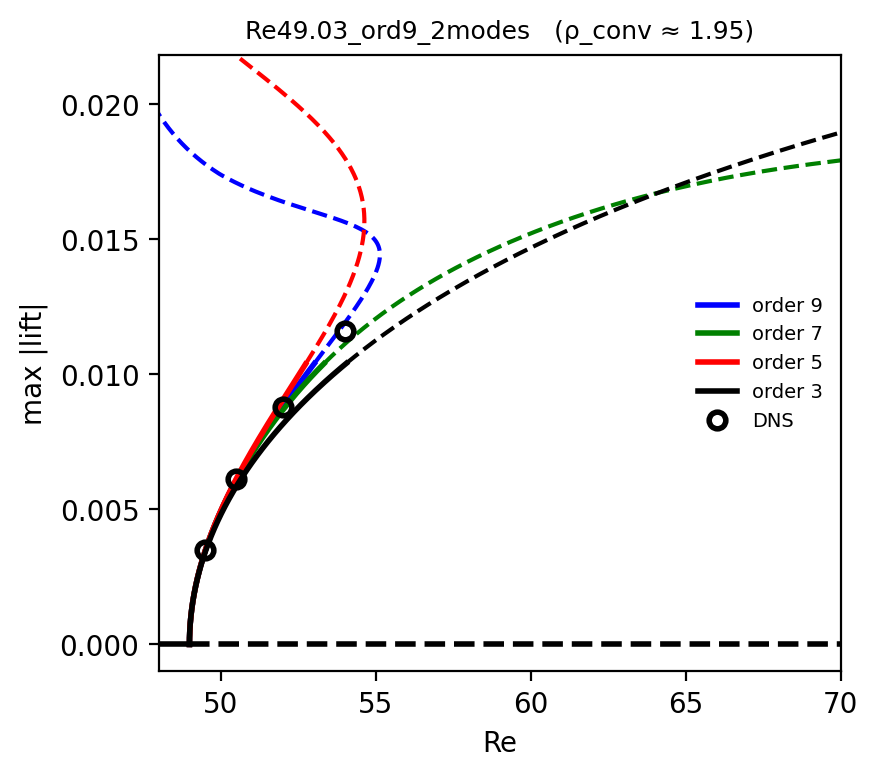

**lift_vs_Re_Re49.03_ord9_6modes.png**

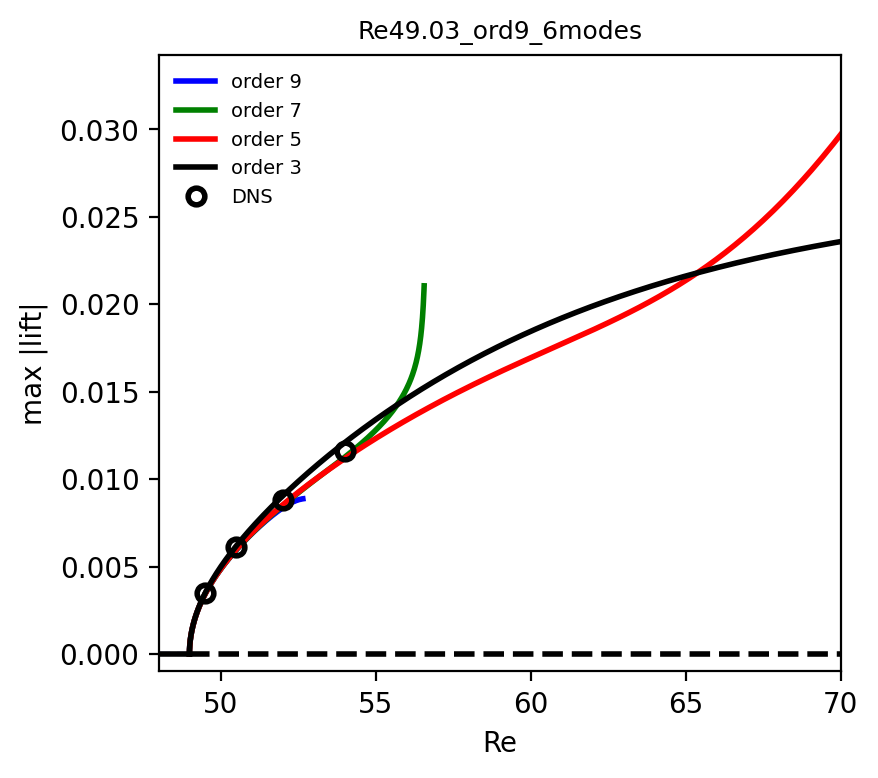

**tke_vs_Re_Re49.03_ord9_2modes.png**

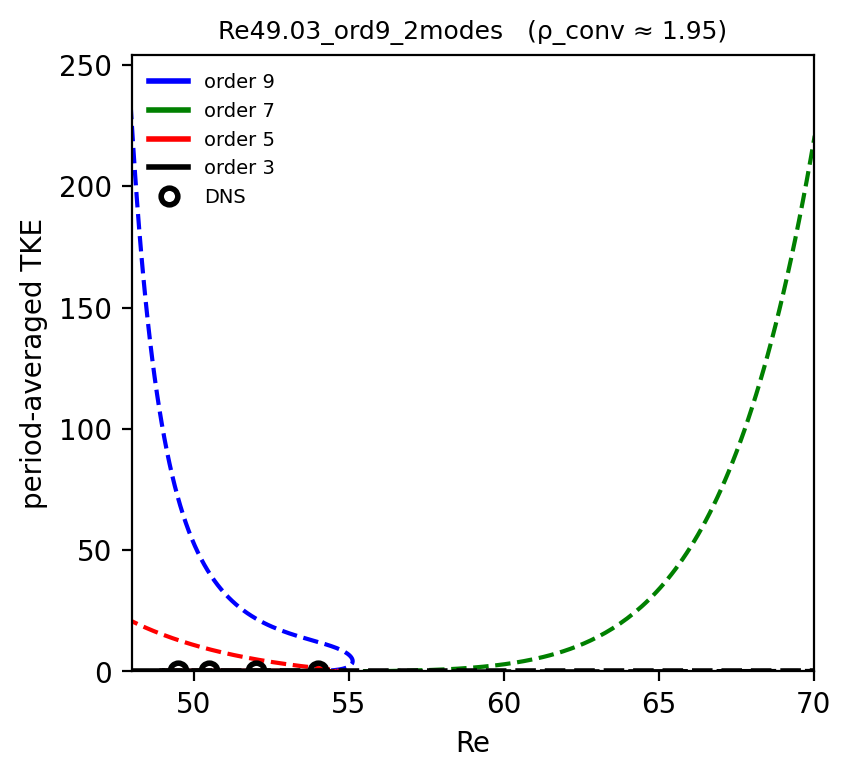

**tke_vs_Re_Re49.03_ord9_6modes.png**

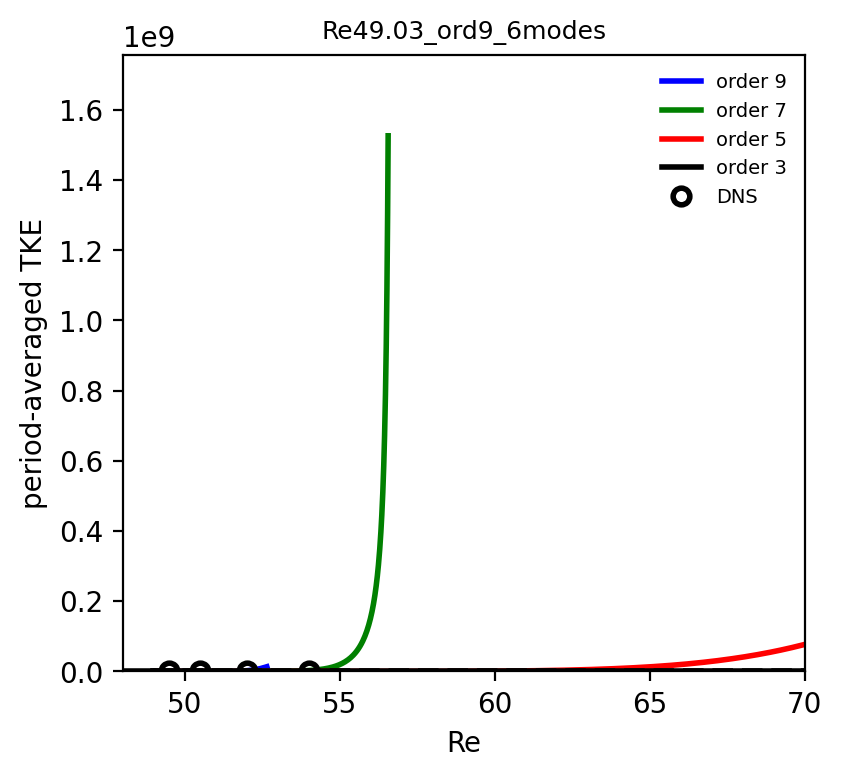

In [15]:
run(`python3 $(joinpath(HERE, "figures.py"))`)

using Base64
for f in sort(filter(p -> endswith(p, ".png"),
		readdir(joinpath(HERE, "results", "comparison"); join = true)))
	display("text/markdown", "**$(basename(f))**")
	display("image/png", read(f))
end

## 14 — DNS reference (optional, heavy)

Direct time integration at 57 860 DOFs with $\Delta t = 5\times10^{-4}$, driven onto a
periodic orbit by ROM-seeded Picard iteration, for each Re in `FOM_REF_RE`. This is
**hours** of compute and belongs on dedicated hardware — hence the flag.

It is what makes the $Re > 54$ part of the figures falsifiable: the existing reference
stops at Re 54, which is precisely where the ROM is still accurate, so it currently
cannot discriminate between truncation orders in the range where they disagree.

In [ ]:
const RUN_FOM = get(ENV, "MORFE_RUN_FOM", "0") == "1"

# Per-Re DNS sweep. The kernels live in MORFEFerrite.FluidNavierStokes; this is the
# bookkeeping around them, ported from the old fom_reference.jl `process_dir`.
#
# The seed is the subtle part: the branch gives an AMPLITUDE ρ, not a state, so it must be
# lifted through the parametrisation — s_init = real(W(z)) at z₁ = z̄₁ = ρ, phase θ = 0.
# ρ is already in the run's scaled master coordinates, so no rescaling is needed.
#
# ΔL_steady: the observables drop the (0,0,c) monomials, whose FOM counterpart is the
# steady-branch lift change from Re₀ to Re. Without subtracting it the DNS lift carries a
# constant offset the ROM does not have. The steady solve is warm-started along the sweep.
function fom_reference_sweep(; seed_ord = FOM_REF_SEED_ORD, re_targets = FOM_REF_RE)
	seed_csv = joinpath(DATA_DIR, "rom_branch_ord$(seed_ord).csv")
	isfile(seed_csv) || error("no seed branch at $seed_csv — lower FOM_REF_SEED_ORD")
	branch = readdlm(seed_csv, ','; skipstart = 1)
	ops = (; case.B₀, case.B₁, case.K_visc, case.h₀_vec)
	(l_free, _) = lift_functional(case)
	(M_vel, vel_rows, area) = prepare_energy_gram(fom)
	L0_lift = dot(l_free, case.s₀_full[fom.free_dpim])
	s_steady_warm = case.s₀_full
	nvar = length(first(W.poly.multiindex_set.exponents))
	rows = []
	for re_target in sort(re_targets)
		η′ = 1.0 / re_target - 1.0 / Re₀
		seed = seed_from_branch(branch, re_target)
		seed === nothing && (@warn "Re $re_target outside the ROM branch — skipped"; continue)
		(ρ, T_rom) = seed
		@printf("\n● Re = %.3f  (η′ = %+.5e, seed ρ = %.4e, T_ROM = %.6f)\n",
			re_target, η′, ρ, T_rom)
		z = zeros(ComplexF64, nvar)
		z[1] = ρ; z[2] = ρ; z[end] = η′
		s_init = vec(real.(MORFE.Polynomials.evaluate(W.poly, z)))

		t0 = time()
		(s_po, T_fom, E_norm, X_max, μ̂, n_orb, conv) = find_periodic_orbit(
			s_init, η′, T_rom, fom, ops.B₀, ops.B₁, ops.K_visc, ops.h₀_vec;
			Δt = FOM_REF_DT, θ = 0.5, n_spinup = FOM_REF_N_SPINUP,
			γ_spinup = FOM_REF_GAMMA, max_picard = FOM_REF_MAX_PICARD,
			tol = FOM_REF_TOL, lift_weights = l_free, verbose = true)
		conv || @warn "Re $re_target: Picard did not converge"

		(_, _, s_steady) = solve_steady_state(fom; Re0 = re_target,
			s_init = s_steady_warm, tol = 1e-10)
		s_steady_warm = s_steady
		ΔL_steady = dot(l_free, s_steady[fom.free_dpim]) - L0_lift

		obs = measure_orbit(s_po, η′, T_fom, fom, ops, l_free, M_vel, vel_rows, area;
			dt = FOM_REF_DT)
		obs.ok || (@warn "Re $re_target: measurement orbit blew up — skipped"; continue)

		max_abs_lift = maximum(abs, obs.FL_per .- ΔL_steady)
		E_M_rel = X_max > 0.0 ? E_norm / X_max : NaN
		μ = isfinite(μ̂) ? μ̂ : obs.μ_meas
		push!(rows, (; Re = re_target, eta = η′, T_rom, T_fom, omega_fom = 2π / T_fom,
			max_abs_lift, lift_amp = (obs.lift_max - obs.lift_min) / 2,
			avg_TKE = obs.avg_tke, E_M_rel, n_orbits = n_orb, converged = conv))
		@printf("   T_fom = %.6f (%d orbits, rel %.2e, %.0f s) | max|lift| = %.6e | ⟨TKE⟩ = %.6e\n",
			T_fom, n_orb, E_M_rel, time() - t0, max_abs_lift, obs.avg_TKE)
	end
	isempty(rows) && (println("no FOM points computed"); return rows)
	out_csv = joinpath(DATA_DIR, "fom_reference.csv")
	open(out_csv, "w") do io
		println(io, "Re,eta,T_rom,T_fom,omega_fom,max_abs_lift,lift_amp,avg_TKE," *
					"E_M_rel,n_orbits,converged")
		for r in rows
			@printf(io, "%.8f,%.12e,%.10f,%.10f,%.10f,%.10e,%.10e,%.10e,%.3e,%d,%s\n",
				r.Re, r.eta, r.T_rom, r.T_fom, r.omega_fom, r.max_abs_lift,
				r.lift_amp, r.avg_TKE, r.E_M_rel, r.n_orbits, r.converged)
		end
	end
	@printf("\n%d FOM reference points → %s\n", length(rows), out_csv)
	return rows
end

if RUN_FOM
	fom_reference_sweep()
end